In [24]:
# !pip install pandas matplotlib networkx

In [25]:
import pandas as pd
from pprint import pprint
import networkx as nx
import matplotlib.pyplot as plt

In [26]:
# Read CSV file
df = pd.read_csv("Russian cities.csv")
print(df)

                Order        Destination  Distance
0         Blagodarnyy         Budonnovsk        70
1         Blagodarnyy         Svetlograd        68
2          Budonnovsk        Zelenokumsk        60
3          Budonnovsk         Neftekumsk        73
4         Zelenokumsk         Georgievsk        54
5        Novopavlovsk         Georgievsk        29
6        Novopavlovsk         Pyatigorsk        66
7          Pyatigorsk         Georgievsk        46
8          Pyatigorsk  Mineral'nyye Vody        25
9          Pyatigorsk      Zheleznovodsk        21
10         Pyatigorsk          Lermontov        12
11         Pyatigorsk         Yessentuki        18
12         Georgievsk  Mineral'nyye Vody        38
13  Mineral'nyye Vody      Zheleznovodsk        18
14  Mineral'nyye Vody       Nevinnomyssk       110
15  Mineral'nyye Vody        Blagodarnyy       128
16  Mineral'nyye Vody         Svetlograd       153
17         Georgievsk      Zheleznovodsk        54
18      Zheleznovodsk          

In [27]:
# To create node and store in a dictionary
graph = {}
for _, row in df.iterrows():
    order, destination, distance = row["Order"], row["Destination"], row["Distance"]
    graph.setdefault(order, {})[destination] = distance
    graph.setdefault(destination, {})[order] = distance
pprint(graph)

{'Blagodarnyy': {'Budonnovsk': 70,
                 "Mineral'nyye Vody": 128,
                 'Nevinnomyssk': 176,
                 'Svetlograd': 68},
 'Budonnovsk': {'Blagodarnyy': 70, 'Neftekumsk': 73, 'Zelenokumsk': 60},
 'Georgievsk': {"Mineral'nyye Vody": 38,
                'Novopavlovsk': 29,
                'Pyatigorsk': 46,
                'Zelenokumsk': 54,
                'Zheleznovodsk': 54},
 'Ipatovo': {"Izobil'nyy": 124, 'Svetlograd': 53},
 "Izobil'nyy": {'Ipatovo': 124,
                'Mikhaylovsk': 46,
                'Novoaleksandrovsk': 49,
                'Stavropol': 53,
                'Svetlograd': 126},
 'Lermontov': {'Pyatigorsk': 12, 'Zheleznovodsk': 19},
 'Mikhaylovsk': {"Izobil'nyy": 46, 'Stavropol': 15, 'Svetlograd': 85},
 "Mineral'nyye Vody": {'Blagodarnyy': 128,
                       'Georgievsk': 38,
                       'Nevinnomyssk': 110,
                       'Pyatigorsk': 25,
                       'Svetlograd': 153,
                       'Zh

In [28]:
# Code to visualize the graph
def visualize_graph(graph, path=None, seed=69):
    g = nx.Graph()
    for city, neighbors in graph.items():
        for neighbor, distance in neighbors.items():
            g.add_edge(city, neighbor, weight=distance)

    pos = nx.spring_layout(g, seed=seed)
    plt.figure(figsize=(25, 25))
    nx.draw(g, pos, with_labels=True, node_color='pink', node_size=5000, font_size=10, font_weight='bold', edge_color='black')

    edge_labels = nx.get_edge_attributes(g, 'weight')

    # Highlight path edges if path is provided
    if path and len(path) > 1:
        highlight_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        nx.draw_networkx_edges(g, pos, edgelist=highlight_edges, edge_color='red', width=3)

    nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_size=20)
    plt.title("Russian Cities Graph")
    plt.show()

In [29]:
# A-star Algorithm Implementation

def a_star(graph, node_start, node_goal):
    # OPEN and CLOSED lists
    OPEN = {node_start: 0}
    CLOSED = set()
    
    g = {node_start: 0}
    h = {node_start: 0}
    parent = {node_start: None}

    while OPEN:
        # Take from the open list the node node_current with the lowest
        node_current = min(OPEN, key=OPEN.get)

        # if node_current is node_goal we have found the solution
        if node_current == node_goal:
            path = []
            while node_current is not None:
                path.append(node_current)
                node_current = parent[node_current]
            return path[::-1], g[node_goal]

        # Generate each state node_successor that come after node_current
        for node_successor, cost in graph.get(node_current, {}).items():
            successor_current_cost = g[node_current] + cost
            
            if node_successor in OPEN:
                # if g(node_successor) <= successor_current_cost then continue
                if g[node_successor] <= successor_current_cost:
                    continue
            elif node_successor in CLOSED:
                # if g(node_successor) <= successor_current_cost then continue
                if g[node_successor] <= successor_current_cost:
                    continue
                # Move node_successor from the CLOSED list to the OPEN list
                CLOSED.remove(node_successor)
                OPEN[node_successor] = float("inf")
            else:
                # Add node_successor to the OPEN list
                OPEN[node_successor] = float("inf")

            # h(node_successor) = heuristic (0 here since we don't have the information for the given dataset)
            # This will act as Dijkstra's algorithm
            h[node_successor] = 0
            g[node_successor] = successor_current_cost

            # Set the parent of node_successor to node_current
            parent[node_successor] = node_current

            # Update f(node_current) = g(node_current) + h(node_current)
            OPEN[node_successor] = g[node_successor] + h[node_successor]

        # Move current from OPEN to CLOSED
        del OPEN[node_current]
        CLOSED.add(node_current)

    # default No solution
    return None, float("inf")

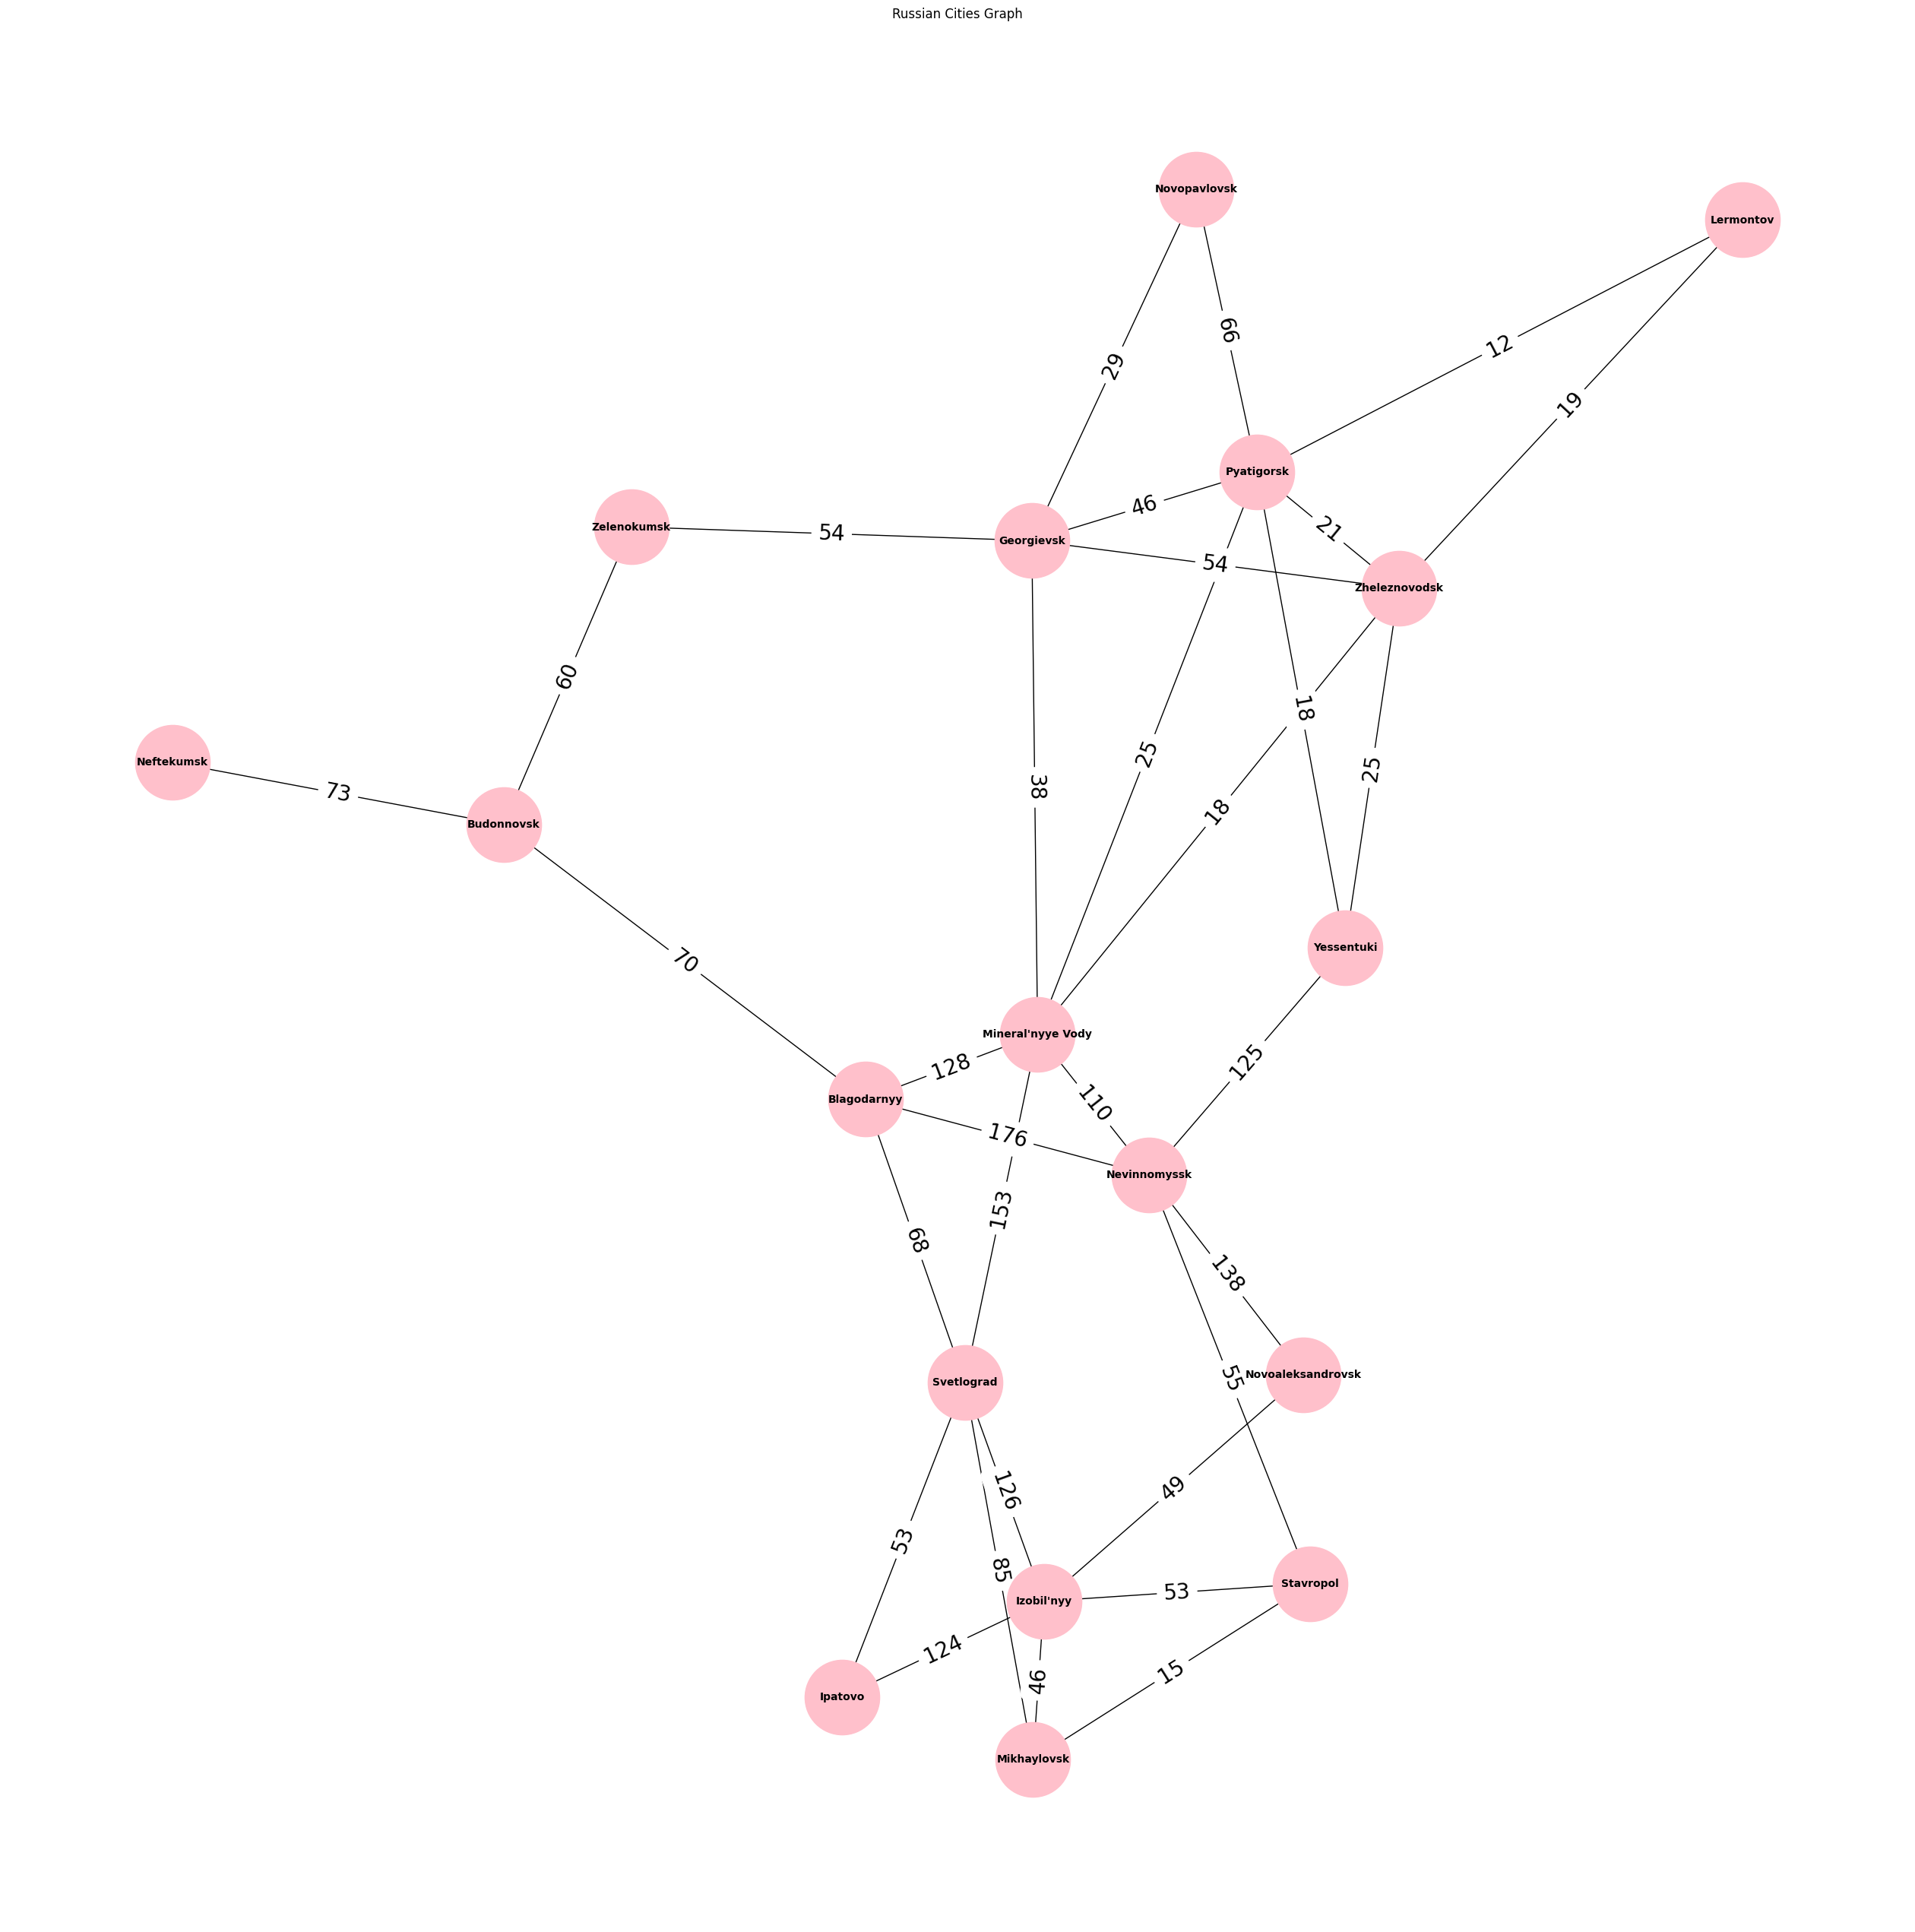

In [30]:
visualize_graph(graph)

Shortest Path: ['Mikhaylovsk', 'Stavropol', 'Nevinnomyssk', "Mineral'nyye Vody", 'Georgievsk', 'Zelenokumsk']
Total Distance: 272


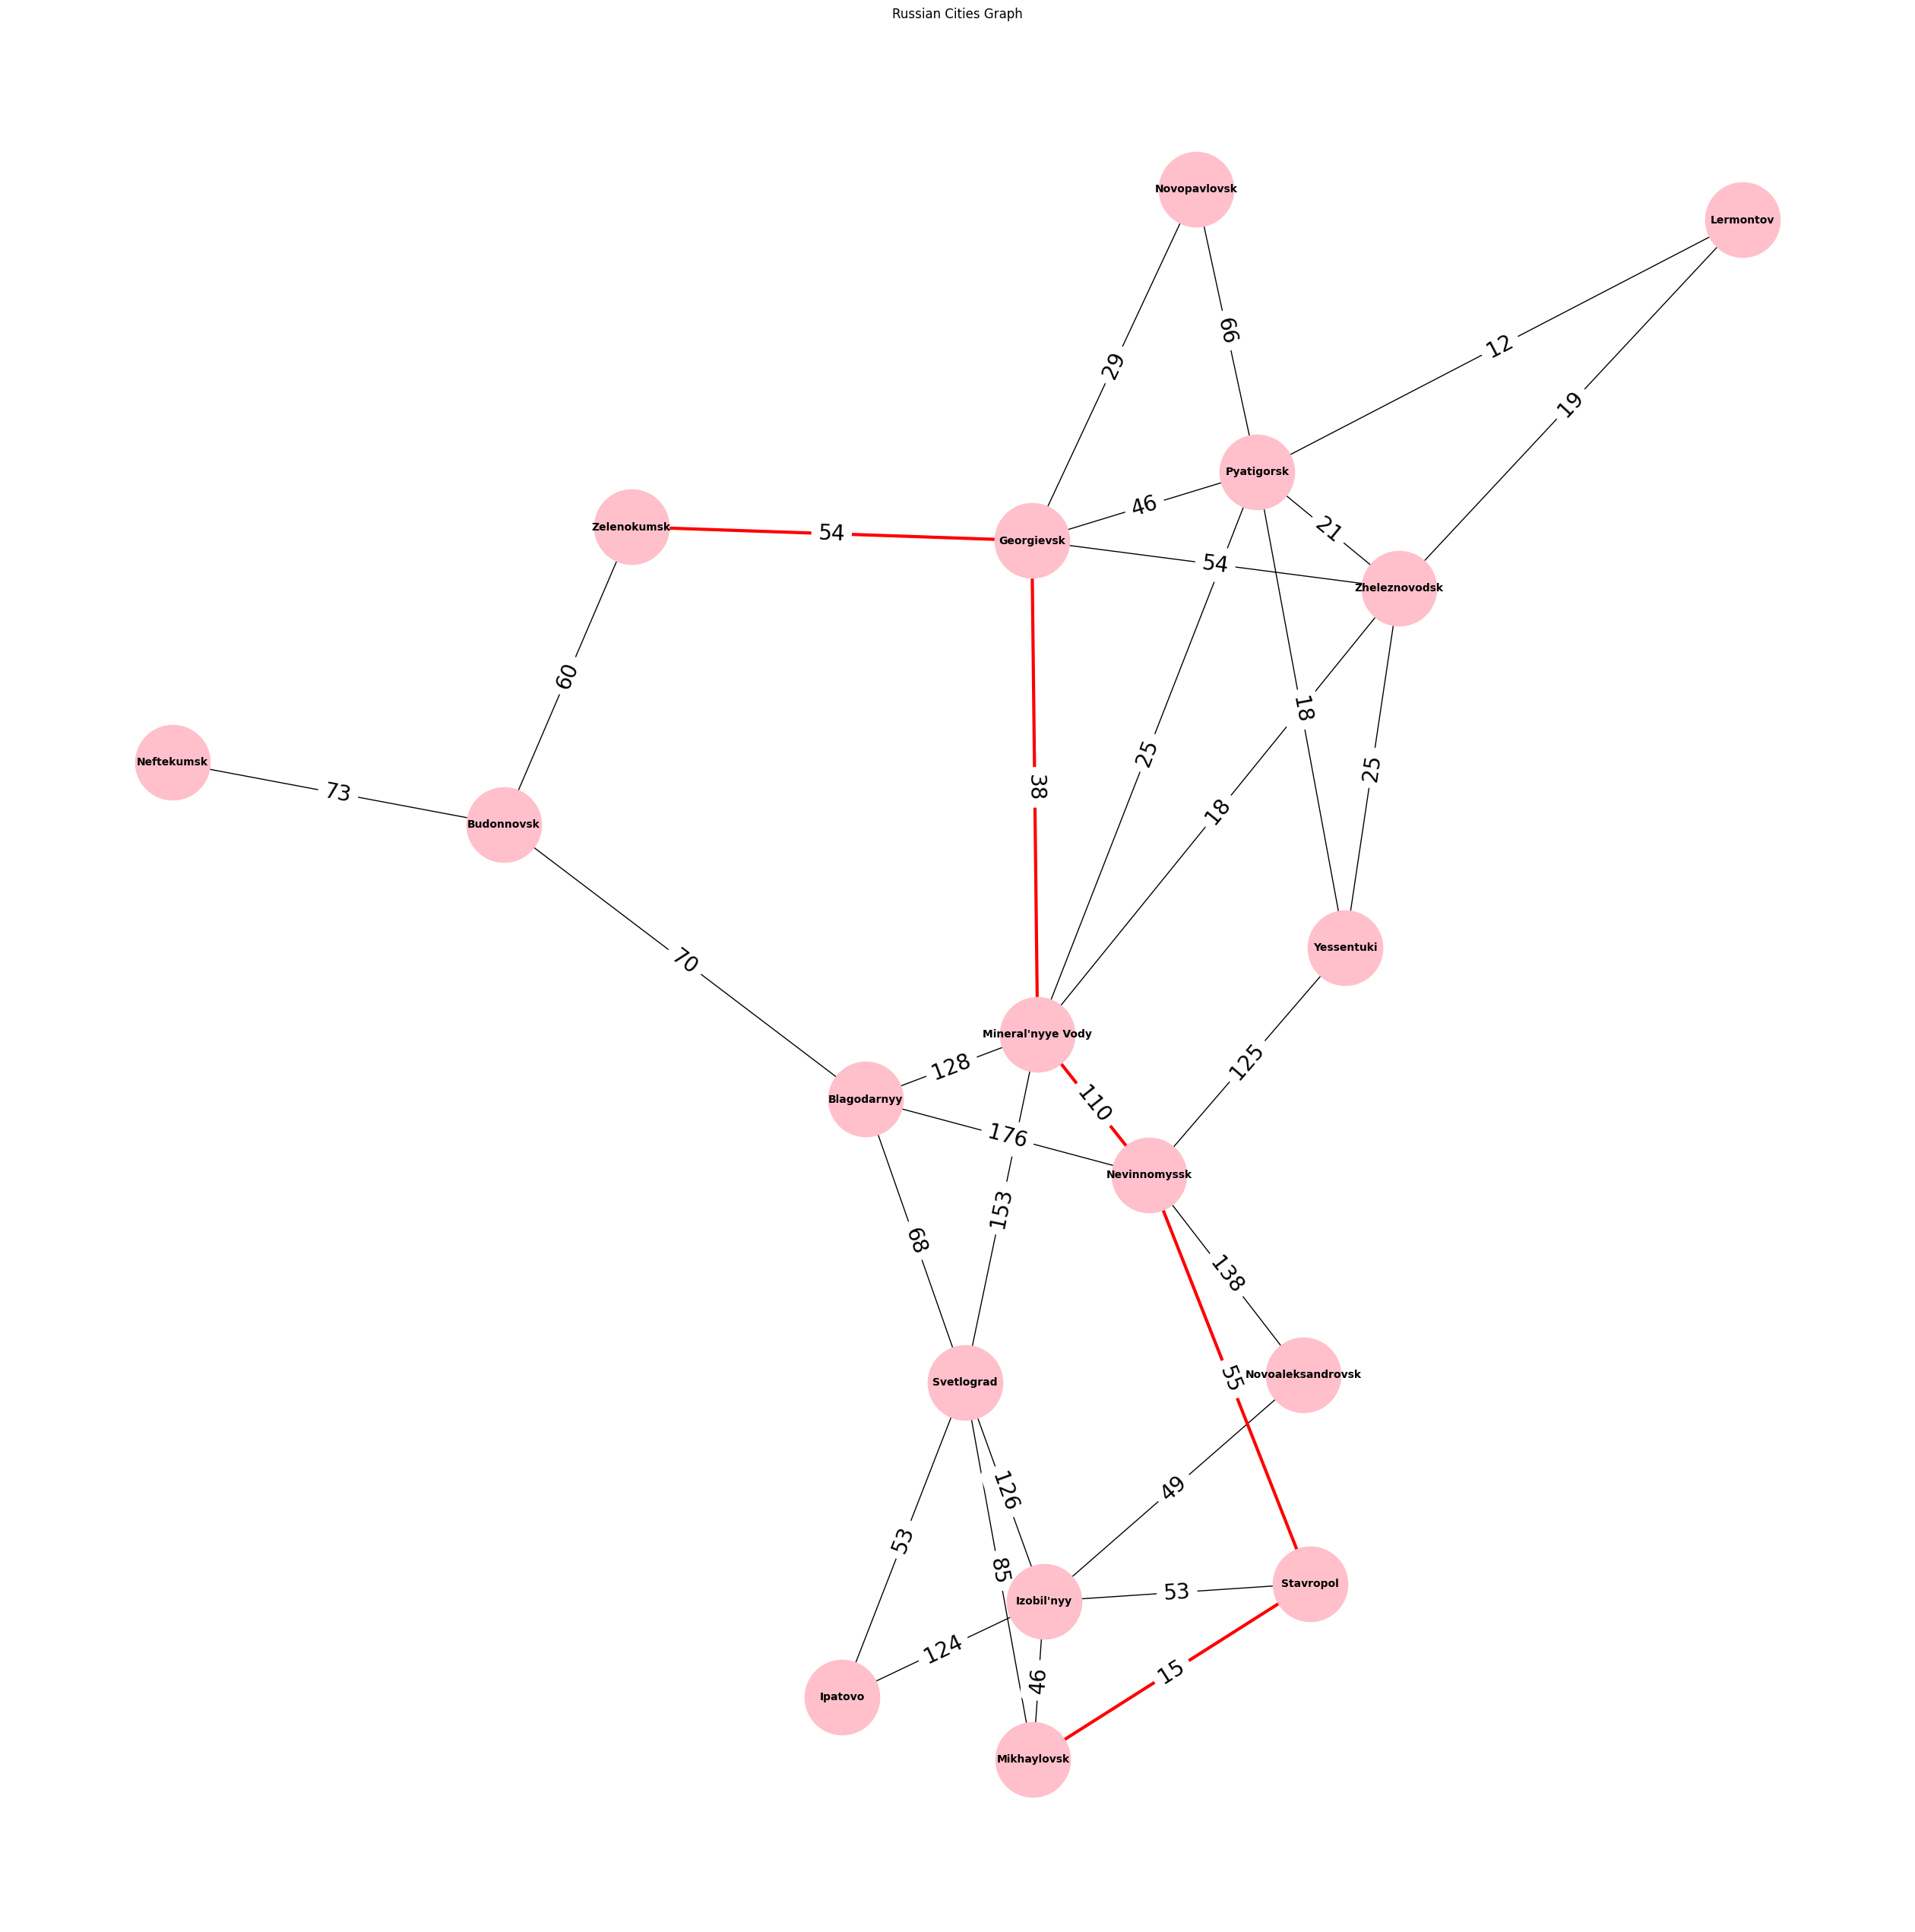

In [31]:
# Example run: Nevinnomyssk -> Lermontov
path, cost = a_star(graph, "Mikhaylovsk", "Zelenokumsk")
print("Shortest Path:", path)
print("Total Distance:", cost)
visualize_graph(graph, path)